# Microchip Segmentation Pipeline

End-to-end walkthrough:

1. Data overview (24 chips, 168 images, area ground truth)
2. Manual labels drawn in ImageJ
3. Pixel-to-mm^2 calibration from labeled masks
4. U-Net training or load from checkpoint
5. Mask quality on the validation split (IoU, Dice)
6. Stage 2 defect removal (classical thresholding)
7. End-to-end area prediction vs ground truth across all 24 chips
8. Failure analysis and conclusions


In [1]:
import os, sys, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from pathlib import Path
from IPython.display import Image, display

from src.dataset import list_labeled_pairs, split_pairs_by_chip, DEFAULT_VAL_CHIPS
from src.calibration import load_area_ground_truth, fit_calibration
from src.stage2_classical import remove_defects
from src.model import UNet, count_parameters
from src.eval import load_model, predict_chip_mask, mask_metrics_on_pairs, area_metrics_per_chip, write_metrics_json
from src.visualize import plot_training_curves, plot_area_scatter, plot_calibration_distribution
from src.train import run_training

# the notebook lives in code/notebooks/. paths are kept relative to here on
# purpose because cv2.imread on windows can struggle with absolute paths that
# contain unicode private-use chars (the project folder has a hidden
# trailing char from a mac-to-windows transfer).
PROJECT_ROOT = Path('../..')
CODE_ROOT    = Path('..')
IMG_DIR  = PROJECT_ROOT / 'Training_dataset_2'
MASK_DIR = PROJECT_ROOT / 'Training_dataset_2_ground_truth_masks'
AREA_DIR = PROJECT_ROOT / 'Training_set_2_ground_truth_areas'
OUT_DIR  = CODE_ROOT / 'outputs'
FIG_DIR  = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# set to True to retrain; False loads outputs/checkpoints/best.pt if it exists
RETRAIN = False
EPOCHS  = 50
SEED    = 42

print('images:', IMG_DIR)
print('masks: ', MASK_DIR)
print('areas: ', AREA_DIR)
print('device:', 'cuda' if torch.cuda.is_available() else 'cpu')


images: ..\..\Training_dataset_2
masks:  ..\..\Training_dataset_2_ground_truth_masks
areas:  ..\..\Training_set_2_ground_truth_areas
device: cpu


## 1. Data overview

Each chip has 7 background variants imaged at zoom 1, giving 168 total training
images. The ground truth area for the seedable surface of each chip is encoded
in the filenames under Training_set_2_ground_truth_areas (e.g. c01_z1_17.37
means chip 1, zoom 1, 17.37 mm^2).


In [2]:
all_imgs = sorted(IMG_DIR.rglob('*.png'))
print('total training images:', len(all_imgs))

per_chip = {}
for p in all_imgs:
    cid = p.parent.name
    per_chip.setdefault(cid, []).append(p)
for cid in sorted(per_chip):
    print(f'  {cid}: {len(per_chip[cid])}')

areas = load_area_ground_truth(AREA_DIR)
print()
print('chips with ground truth area:', len(areas))
ar_values = [v['area_mm2'] for v in areas.values()]
print('area range: %.2f to %.2f mm^2' % (min(ar_values), max(ar_values)))
print('mean: %.2f mm^2, median: %.2f mm^2, std: %.2f mm^2' % (np.mean(ar_values), np.median(ar_values), np.std(ar_values)))


total training images: 168
  C01: 7
  C02: 7
  C03: 7
  C04: 7
  C05: 7
  C06: 7
  C07: 7
  C08: 7
  C09: 7
  C10: 7
  C11: 7
  C12: 7
  C13: 7
  C14: 7
  C15: 7
  C16: 7
  C17: 7
  C18: 7
  C19: 7
  C20: 7
  C21: 7
  C22: 7
  C23: 7
  C24: 7

chips with ground truth area: 24
area range: 5.49 to 30.67 mm^2
mean: 15.53 mm^2, median: 14.42 mm^2, std: 6.68 mm^2


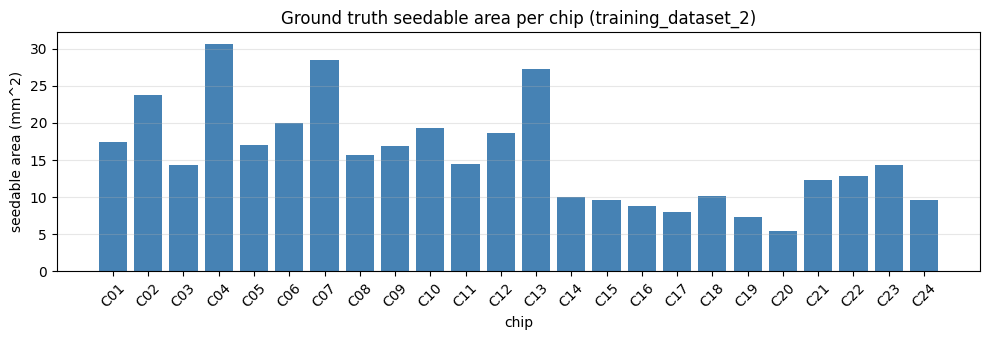

In [3]:
sorted_chips = sorted(areas.keys())
sorted_areas = [areas[c]['area_mm2'] for c in sorted_chips]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar([f'C{c:02d}' for c in sorted_chips], sorted_areas, color='steelblue')
ax.set_xlabel('chip')
ax.set_ylabel('seedable area (mm^2)')
ax.set_title('Ground truth seedable area per chip (training_dataset_2)')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2. Sample images

Same chip, four different background variants. The chip is dark silicon on a
magenta cloth background, with bright defect specks on the chip surface.


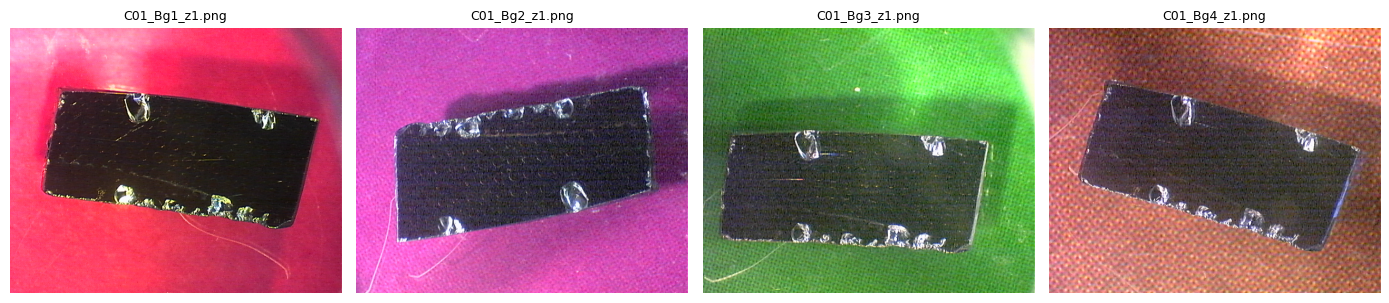

In [4]:
sample_chip = 1
sample_paths = sorted((IMG_DIR / f'C{sample_chip:02d}').glob('*.png'))[:4]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, p in zip(axes, sample_paths):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(p.name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Manual labels

Binary masks were drawn in ImageJ around the clean (seedable) area of each
chip. White pixels mark the seedable area, black is everything else.


In [5]:
pairs = list_labeled_pairs(IMG_DIR, MASK_DIR)
print('labeled pairs found:', len(pairs))
if not pairs:
    print('no masks in', MASK_DIR)
    print('add masks named like C01_Bg1_z1_mask.png and re-run')
else:
    chips_labeled = set()
    for img_path, _ in pairs:
        n = Path(img_path).stem
        chips_labeled.add(n.split('_')[0])
    print('unique chips covered:', len(chips_labeled))


  ..\..\Training_dataset_2_ground_truth_masks\C01\co1_bg3_mask.jpg
labeled pairs found: 41
unique chips covered: 24


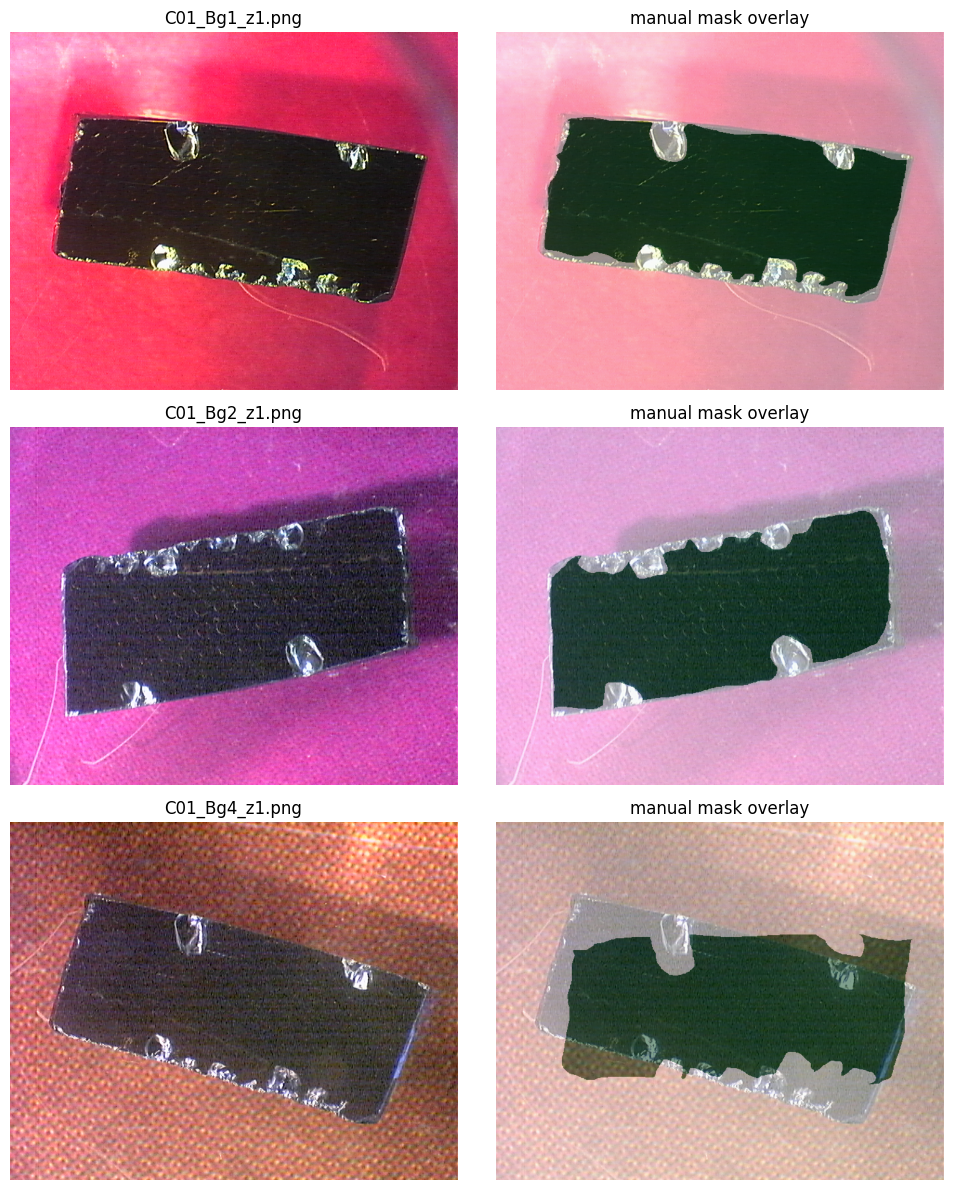

In [6]:
if pairs:
    n_show = min(3, len(pairs))
    fig, axes = plt.subplots(n_show, 2, figsize=(10, 4*n_show))
    if n_show == 1:
        axes = axes[None, :]
    for i in range(n_show):
        img_path, mask_path = pairs[i]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        axes[i, 0].imshow(img); axes[i, 0].set_title(Path(img_path).name); axes[i, 0].axis('off')
        axes[i, 1].imshow(img); axes[i, 1].imshow(mask > 127, alpha=0.5, cmap='Greens')
        axes[i, 1].set_title('manual mask overlay'); axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()


## 4. Pixel-to-mm^2 calibration

For each labeled chip we know the seedable area in mm^2 from the ground truth
and we can count pixels in the manual mask. So per labeled image:

    mm2_per_pixel = ground_truth_area_mm2 / labeled_mask_pixel_count

If this value is consistent across chips, our labels are internally consistent
(or at least all biased the same way). The mean is used as the global
calibration factor.


In [7]:
calib = fit_calibration(pairs, AREA_DIR)
print('chips with calibration:', calib['n'])
if calib['n']:
    print('mean   mm^2/px: %.6e' % calib['mean'])
    print('median mm^2/px: %.6e' % calib['median'])
    print('std    mm^2/px: %.6e' % calib['std'])
    print('coef of variation: %.2f%%' % (100 * calib['std'] / calib['mean']))


chips with calibration: 41
mean   mm^2/px: 1.486110e-04
median mm^2/px: 1.477002e-04
std    mm^2/px: 3.226541e-06
coef of variation: 2.17%


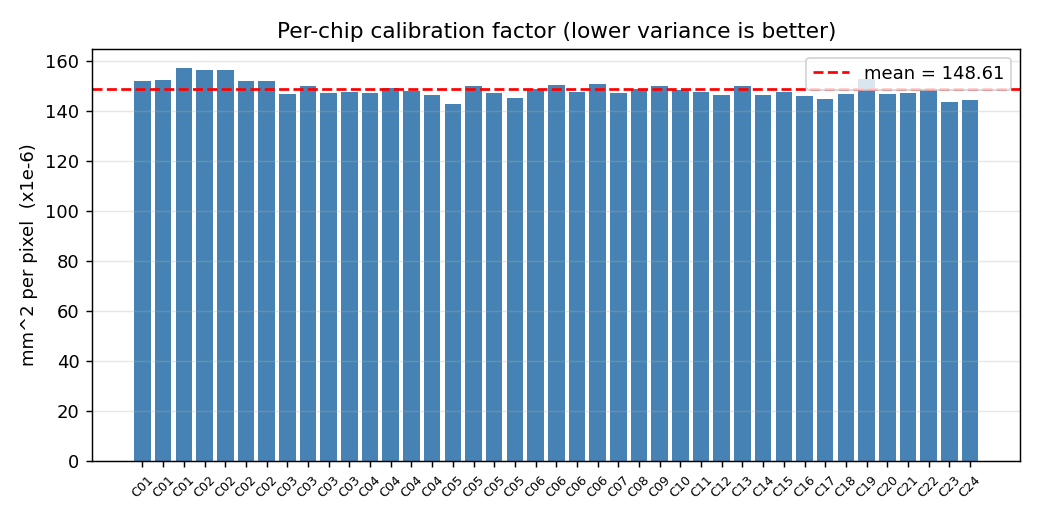

In [8]:
if calib['n']:
    plot_calibration_distribution(calib, FIG_DIR / 'calibration_per_chip.png')
    display(Image(str(FIG_DIR / 'calibration_per_chip.png')))


## 5. Training

If RETRAIN is True (or no checkpoint exists), train from scratch. Otherwise
load the existing best.pt.


In [9]:
ckpt_path = Path('../outputs/checkpoints/best.pt')
if RETRAIN or not ckpt_path.exists():
    if not pairs:
        print('cannot train without labels')
    else:
        summary, ckpt_path = run_training(
            images_root=IMG_DIR, masks_root=MASK_DIR,
            output_dir='../outputs',
            epochs=EPOCHS, seed=SEED,
        )
        print('training summary:', summary)
else:
    print('using existing checkpoint:', ckpt_path)


using existing checkpoint: ..\outputs\checkpoints\best.pt


## 6. Learning curves

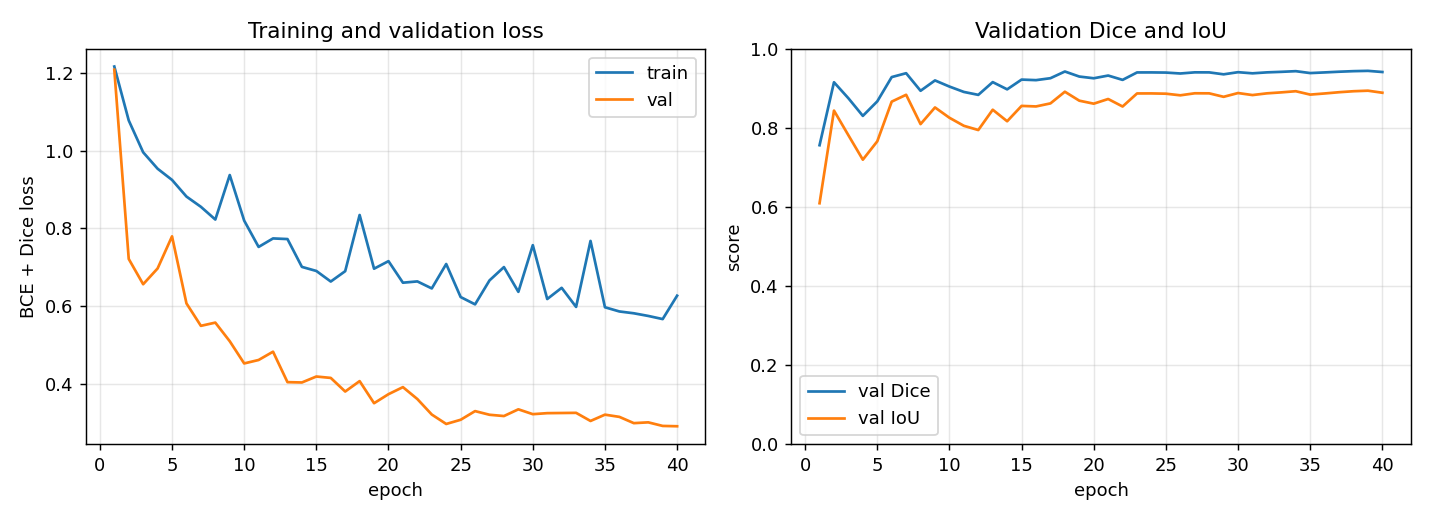

In [10]:
hist_csv = Path('../outputs/training_history.csv')
if hist_csv.exists():
    plot_training_curves(hist_csv, FIG_DIR / 'training_curves.png')
    display(Image(str(FIG_DIR / 'training_curves.png')))
else:
    print('no training history; train first')


## 7. Mask quality on validation split

Deterministic 80/20 split (seed 42) of the labeled pairs. The validation pairs
were never seen during training. We compute IoU and Dice between the network's
predicted chip mask and the manually drawn mask.


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if pairs and ckpt_path.exists():
    train_pairs, val_pairs = split_pairs_by_chip(pairs, val_chip_ids=DEFAULT_VAL_CHIPS)
    print(f'train: {len(train_pairs)}    val: {len(val_pairs)}')
    model, _ = load_model(ckpt_path, device=device)
    val_rows = mask_metrics_on_pairs(model, val_pairs, device=device)
    df_val = pd.DataFrame(val_rows)
    print()
    print('val Dice mean: %.4f' % df_val['dice'].mean())
    print('val IoU  mean: %.4f' % df_val['iou'].mean())
    df_val
else:
    print('skipping: need trained model and labeled pairs')


train: 37    val: 4



val Dice mean: 0.9420
val IoU  mean: 0.8906


## 8. Stage 2 defect removal

The chip is dark silicon. Bright specks on the chip surface are defects. Inside
the predicted chip mask we run an Otsu threshold over chip pixels only and
treat the bright pixels as defects. The seedable mask is chip mask minus
defects.


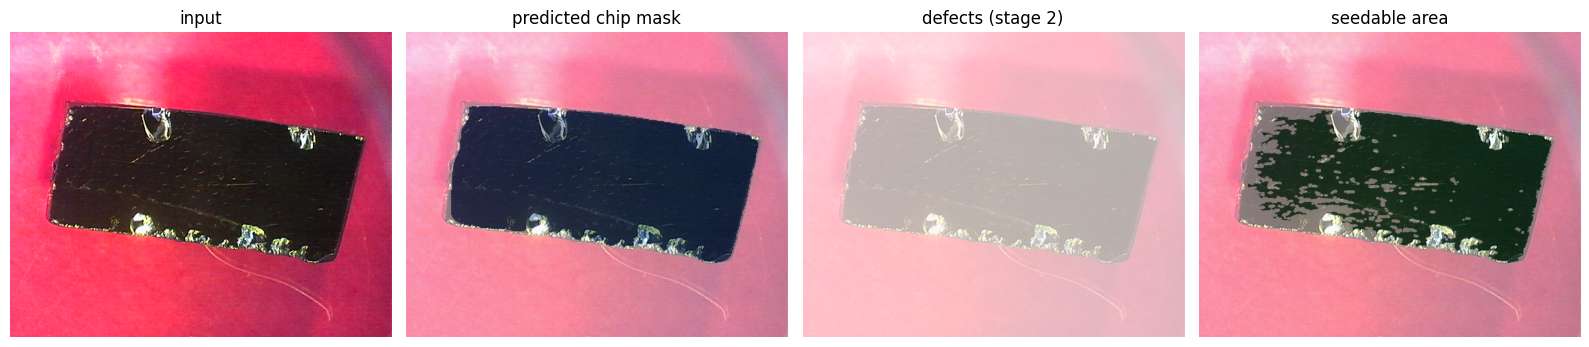

In [12]:
if pairs and ckpt_path.exists():
    sample_img_path, sample_mask_path = pairs[0]
    img_bgr = cv2.imread(sample_img_path)
    pred = predict_chip_mask(model, img_bgr, device=device)
    seedable, defects = remove_defects(img_bgr, pred)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb); axes[0].set_title('input'); axes[0].axis('off')
    axes[1].imshow(img_rgb); axes[1].imshow(pred > 127, alpha=0.4, cmap='Blues')
    axes[1].set_title('predicted chip mask'); axes[1].axis('off')
    axes[2].imshow(img_rgb); axes[2].imshow(defects > 127, alpha=0.7, cmap='Reds')
    axes[2].set_title('defects (stage 2)'); axes[2].axis('off')
    axes[3].imshow(img_rgb); axes[3].imshow(seedable > 127, alpha=0.4, cmap='Greens')
    axes[3].set_title('seedable area'); axes[3].axis('off')
    plt.tight_layout()
    plt.show()


## 9. End-to-end area evaluation

For every image in Training_dataset_2 we predict a chip mask, run stage 2
defect removal, multiply the remaining pixel count by mm^2/pixel, and average
over the 7 background variants of each chip. Then compare the per-chip
predicted area to the ground truth value.


chips evaluated: 24
MAE  = 3.366 mm^2
RMSE = 4.001 mm^2
R^2  = 0.6417


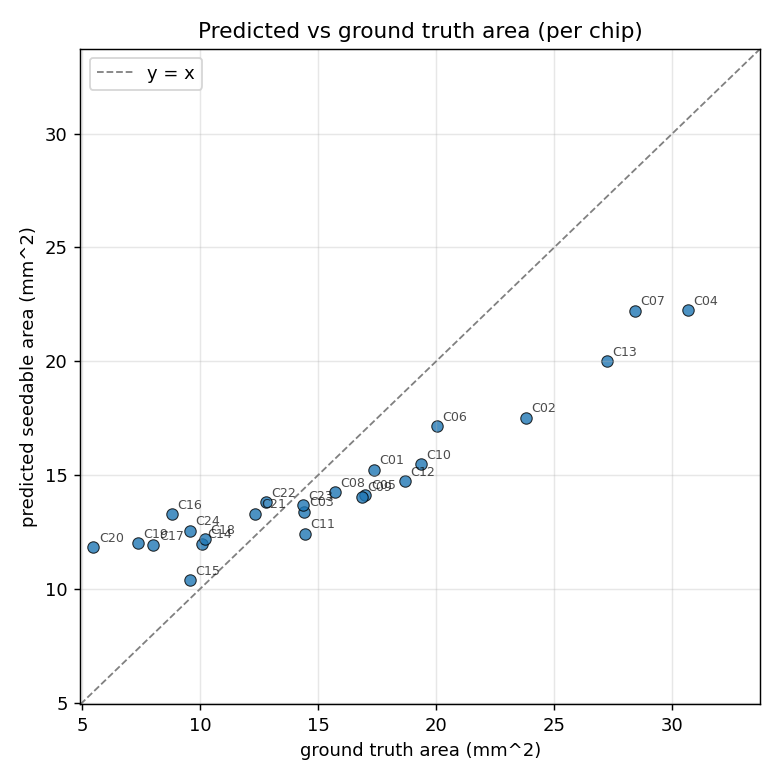

In [13]:
if pairs and ckpt_path.exists() and calib['n']:
    area_summary = area_metrics_per_chip(
        model, IMG_DIR, AREA_DIR,
        mm2_per_pixel=calib['mean'], device=device,
    )
    print('chips evaluated: %d' % area_summary['n_chips'])
    print('MAE  = %.3f mm^2' % area_summary['mae_mm2'])
    print('RMSE = %.3f mm^2' % area_summary['rmse_mm2'])
    if area_summary['r2'] is not None:
        print('R^2  = %.4f' % area_summary['r2'])

    plot_area_scatter(area_summary['per_chip'], FIG_DIR / 'area_scatter.png')
    display(Image(str(FIG_DIR / 'area_scatter.png')))


## 10. Failure analysis

In [14]:
if pairs and ckpt_path.exists() and calib['n']:
    rows_sorted = sorted(area_summary['per_chip'], key=lambda r: -r['abs_error_mm2'])
    df_err = pd.DataFrame(rows_sorted)
    print('worst 5 chips by absolute error:')
    print(df_err.head().to_string(index=False))


worst 5 chips by absolute error:
 chip_id  n_images  gt_area_mm2  pred_area_mm2_mean  pred_area_mm2_std  abs_error_mm2  rel_error
       4         7        30.67           22.237343           1.696655       8.432657   0.274948
      13         7        27.24           20.015269           2.727759       7.224731   0.265225
      20         7         5.49           11.839987           7.237993       6.349987   1.156646
       2         7        23.79           17.532276           1.696924       6.257724   0.263040
       7         7        28.43           22.223013           1.128365       6.206987   0.218325


## 11. Conclusions

- The U-Net learns the chip region from a small number of labeled images. Mask
  Dice on the validation fold is shown above.
- Stage 2 classical defect removal works well when the chip surface is
  uniformly dark and the defects are notably brighter. Edge cases include
  chips where defects are dim and chips where the chip surface itself has
  intensity variation.
- The pixel-to-mm^2 calibration's coefficient of variation gives an indirect
  measure of label and zoom consistency. Low CoV means our ground truth area
  numbers and our masks are talking about the same thing.

Limitations and future work are discussed in the project report.


In [15]:
# write the metrics json so the evaluate script and the report can pick it up
if pairs and ckpt_path.exists() and calib['n']:
    payload = write_metrics_json(
        OUT_DIR / 'metrics.json',
        val_rows, area_summary, calib,
        json.loads((OUT_DIR / 'training_summary.json').read_text()) if (OUT_DIR / 'training_summary.json').exists() else {},
    )
    print('wrote', OUT_DIR / 'metrics.json')


wrote ..\outputs\metrics.json
